# Test on Fourier-space interpolation task of Kolmogorov flow

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import namedtuple
from einops import rearrange
from torch_ema import ExponentialMovingAverage
import torch.nn.functional as F

from modules_irsde import get_conditional_unet
from sampling import get_sampling_func
from diffusion import get_diffusion
from corruptions import get_corrupt_sr
from datasets import get_bound_func
from utils import *

data_name = 'kol'
version = 'pretrain_fi'      # change to the version of your own run
opt_path = './__results__/' + data_name + '_' + version + '/opt.json'
with open(opt_path, 'r', encoding='utf-8') as f:
    opt = json.load(f)
OPT_class = namedtuple('OPT_class', opt.keys())
opt = OPT_class(**opt)

## Load model

In [2]:
net = get_conditional_unet(opt)
ema = ExponentialMovingAverage(net.parameters(), decay=opt.ema_rate)
checkpoint_path = opt.results_path + '/checkpoint_tunePF.pt'   # use '/checkpoint.pt' for untuned model and '/checkpoint_tunePF.pt' for finetuned model

checkpoint = torch.load(checkpoint_path, map_location="cpu")
net.load_state_dict(checkpoint['net'])
print(f"[Net] Loaded network ckpt: {checkpoint_path}!")
try:
    ema.load_state_dict(checkpoint["ema"])
    ema.to(opt.device)
    print(f"[Ema] Loaded ema ckpt: {checkpoint_path}!")
except:
    ema = None
    print('No ema found!')

# load logging of rewards...
try:
    logging = np.load(opt.results_path + '/tuneRL_logging.npy', allow_pickle=True).item()
except:
    logging = None
    print('No logging found!')

net = nn.DataParallel(net)
net.to(opt.device).eval()
diffusion = get_diffusion(opt)
corrupt_func = get_corrupt_sr(scale=opt.scale, recon_method='bicubic', noise=True)
mean, std = np.load(opt.results_path + '/mean_std.npy')
scalar = lambda x: (x-mean)/std
scalar_inv = lambda x: x*std+mean
bound_func = get_bound_func('periodic', num_grid=2)
print('scale: ', opt.scale)

[Net] Loaded network ckpt: ./__results__/kol_pretrain_fi/checkpoint_tunePF.pt!
No ema found!
No logging found!
scale:  8


## Load data

In [3]:
data_raw_high = np.load("/media/group3/lzy/Data/kol/kf_2d_re1000_256_40seed_bthwc.npy")
x_test_high = scalar(data_raw_high)

t_start = 200
ns_real = 30
samples_high = []
for i in range(ns_real):
    samples_high.append(x_test_high[-4:-3, t_start+i*3:t_start+i*3+opt.num_frames, :, :, 0])
samples_high = np.concatenate(samples_high)
# samples_high = bound_func(samples_high)
print(samples_high.shape)

(30, 3, 256, 256)


## Sampling

In [4]:
nfe = 10     # sample steps
log_count = 10
# x1_lr, x1 = corrupt_func(torch.from_numpy(samples_high).float(), noise=0.1)
x1_lr = torch.from_numpy(samples_high).float()[..., ::opt.scale, ::opt.scale]
x1_lr = x1_lr + torch.randn_like(x1_lr)*0.05
x1 = F.interpolate(bound_func(x1_lr), scale_factor=opt.scale, mode='bicubic', align_corners=False)    # , align_corners=False
cond = x1.clone()
# x1 = x1 + torch.randn_like(x1)*0.01
sampling_func = get_sampling_func(net, ema, num_scales=opt.num_scales, nfe=nfe, diffusion=diffusion, log_count=log_count, device=opt.device, ot_ode=False, es=True)
with torch.no_grad():
    xs, x0s = sampling_func(x1, cond)
print(xs.shape, x0s.shape)
padding = 2
xs = xs[..., opt.scale*padding:-opt.scale*padding, opt.scale*padding:-opt.scale*padding]
x0s = x0s[..., opt.scale*padding:-opt.scale*padding, opt.scale*padding:-opt.scale*padding]
x1 = x1[..., opt.scale*padding:-opt.scale*padding, opt.scale*padding:-opt.scale*padding]
torch.cuda.empty_cache()

DDPM sampling: 100%|██████████| 10/10 [00:19<00:00,  1.93s/it]

torch.Size([30, 10, 3, 288, 288]) torch.Size([30, 10, 3, 288, 288])


## Visulization

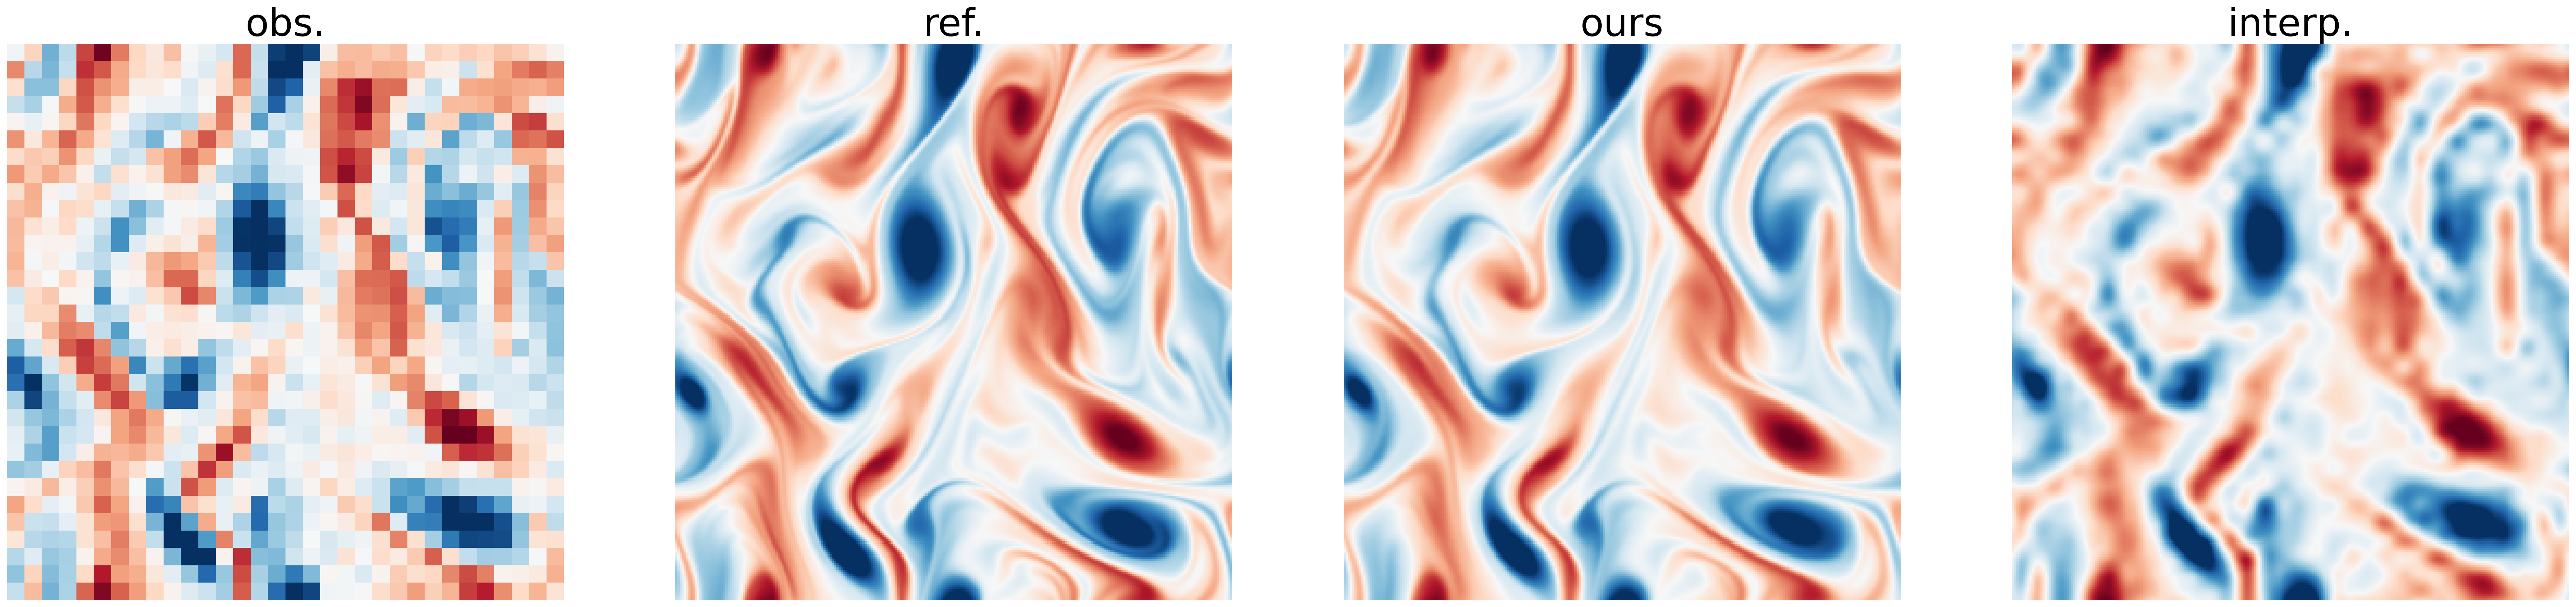

nRMSE for PalSB:  0.09085655098476582
nRMSE for interp.:  0.5679296945788369


In [5]:
import matplotlib.pyplot as plt
i_b = 0
i_t = 1
i_f = -1
x_plots = [x1_lr[i_b, i_t], samples_high[i_b, i_t], x0s[i_b, i_f, i_t], x1[i_b, i_t].detach().cpu()]
titles = ['obs.', 'ref.', 'ours', 'interp.']
fig, axes = plt.subplots(1, 4, figsize=(48, 12), dpi=200)
for i in range(len(x_plots)):
    axes[i].pcolormesh(x_plots[i], cmap='RdBu_r', vmin=-2.5, vmax=2.5)
    axes[i].set_aspect(1)
    axes[i].set_title(titles[i], fontsize=40)
    axes[i].axis('off')
plt.show()
# fig.savefig(opt.results_path + '/test.png', dpi=600)
print('nRMSE for PalSB: ', cal_rmse(samples_high, x0s[:, i_f].numpy(), normalize=True).mean())     # (abs(samples_high-x0s[:, i_f].numpy())).mean()
print('nRMSE for interp.: ', cal_rmse(samples_high, x1.detach().cpu().numpy(), normalize=True).mean())

## Equation residuals

In [6]:
def voriticity_residual(w, re=1000.0, dt=1/32):
    # w [b t h w]
    batchsize = w.size(0)
    w = w.clone()
    w.requires_grad_(True)
    nx = w.size(2)
    ny = w.size(3)
    device = w.device

    w_h = torch.fft.fft2(w[:, 1:-1], dim=[2, 3])
    # Wavenumbers in y-direction
    k_max = nx//2
    N = nx
    k_x = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).\
        reshape(N, 1).repeat(1, N).reshape(1,1,N,N)
    k_y = torch.cat((torch.arange(start=0, end=k_max, step=1, device=device),
                     torch.arange(start=-k_max, end=0, step=1, device=device)), 0).\
        reshape(1, N).repeat(N, 1).reshape(1,1,N,N)
    # Negative Laplacian in Fourier space
    lap = (k_x ** 2 + k_y ** 2)
    lap[..., 0, 0] = 1.0
    psi_h = w_h / lap

    u_h = 1j * k_y * psi_h
    v_h = -1j * k_x * psi_h
    wx_h = 1j * k_x * w_h
    wy_h = 1j * k_y * w_h
    wlap_h = -lap * w_h

    u = torch.fft.irfft2(u_h[..., :, :k_max + 1], dim=[2, 3])
    v = torch.fft.irfft2(v_h[..., :, :k_max + 1], dim=[2, 3])
    wx = torch.fft.irfft2(wx_h[..., :, :k_max + 1], dim=[2, 3])
    wy = torch.fft.irfft2(wy_h[..., :, :k_max + 1], dim=[2, 3])
    wlap = torch.fft.irfft2(wlap_h[..., :, :k_max + 1], dim=[2, 3])
    advection = u*wx + v*wy

    wt = (w[:, 2:, :, :] - w[:, :-2, :, :]) / (2 * dt)

    # establish forcing term
    x = torch.linspace(0, 2*np.pi, nx + 1, device=device)
    x = x[0:-1]
    X, Y = torch.meshgrid(x, x)
    f = -4*torch.cos(4*Y)

    residual = wt + (advection - (1.0 / re) * wlap + 0.1*w[:, 1:-1]) - f
    residual_loss = (residual**2).mean()
    dw = torch.autograd.grad(residual_loss, w)[0]
    return dw, residual, residual_loss

dw, res, loss_eq = voriticity_residual(torch.from_numpy(scalar_inv(samples_high)), re=1000, dt=1/32)
dw_, res_, loss_eq_ = voriticity_residual(scalar_inv(x0s[:, -1]), re=1000, dt=1/32)
dw_interp, res_interp, loss_eq_interp = voriticity_residual(scalar_inv(x1), re=1000, dt=1/32)
print('nER for PalSB: ', loss_eq_/(scalar_inv(samples_high)**2).mean().item())
print('nER for interp.: ', loss_eq_interp/(scalar_inv(samples_high)**2).mean().item())

/home/lzy/anaconda3/envs/palsb/lib/python3.9/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


nER for PalSB:  tensor(0.3636, grad_fn=<DivBackward0>)
nER for interp.:  tensor(18.0548, grad_fn=<DivBackward0>)


# Full Test on all test data

In [12]:
from contextlib import contextmanager
import sys, os

@contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:  
            yield
        finally:
            sys.stdout = old_stdout

load_exist = False
data_kw = 'x1'
data_kw_lr = 'x1_lr'
info_kw = 'info'

print(x_test_high.shape)
data_test = []
for traj in x_test_high[-4:]:
    for i in range(len(traj)-opt.num_frames+1):
        h = traj[i:i+opt.num_frames]
        h = rearrange(h, 't h w c -> (t c) h w')
        data_test.append(h)
data_test = np.stack(data_test)
print(data_test.shape)

if load_exist:
    data = np.load('__results__/kol_v17_n005' + '/corrupted_samples_n000.npz')
    sampled_x1, sampled_x1_lr = scalar(data[data_kw]), scalar(data[data_kw_lr])
    noise_level = data[info_kw].item()
    print(f'noise_level: {noise_level}')
else:
    sampled_x1_lr = data_test[..., ::opt.scale, ::opt.scale]
    sampled_x1 = F.interpolate(torch.from_numpy(sampled_x1_lr), scale_factor=opt.scale, mode='bicubic', align_corners=False).numpy()
dataset = torch.utils.data.TensorDataset(torch.from_numpy(sampled_x1))
dataloader = torch.utils.data.DataLoader(dataset, batch_size=36, shuffle=False)

(40, 320, 256, 256, 1)
(1272, 3, 256, 256)


## sampling

In [13]:
from tqdm import tqdm
net.eval()
nfe = 10    # sample steps
log_count = 1
padding = 2
sampling_func = get_sampling_func(net, ema, num_scales=opt.num_scales, nfe=nfe, diffusion=diffusion, log_count=log_count, device=opt.device, ot_ode=True, es=True)
bound_fn = get_bound_func('periodic', num_grid=padding*opt.scale)

sampled_x0 = []
with torch.no_grad():
    for i, (x1,) in tqdm(enumerate(dataloader), total=len(dataloader)):
        x1 = x1.float().to(opt.device)
        if padding > 0:
            x1 = bound_fn(x1)
        cond = x1.clone()
        _, x0s = sampling_func(x1, cond)
        if padding > 0:
            x0s = x0s[..., opt.scale*padding:-opt.scale*padding, opt.scale*padding:-opt.scale*padding]
        sampled_x0.append(x0s[:, -1])
sampled_x0 = torch.cat(sampled_x0)
sampled_x1 = torch.tensor(sampled_x1)
print(sampled_x0.shape, sampled_x1.shape, sampled_x1_lr.shape)
torch.cuda.empty_cache()

100%|██████████| 36/36 [04:12<00:00,  7.02s/it]


torch.Size([1272, 3, 256, 256]) torch.Size([1272, 3, 256, 256]) (1272, 3, 32, 32)


## nRMSE & nER

In [14]:
print('nRMSE for PalSB: ', cal_rmse(data_test, sampled_x0.numpy(), normalize=True).mean())     # (abs(samples_high-x0s[:, i_f].numpy())).mean()
print('nRMSE for interp.: ', cal_rmse(data_test, sampled_x1.numpy(), normalize=True).mean())

dw, res, loss_eq = voriticity_residual(torch.from_numpy(scalar_inv(data_test)), re=1000, dt=1/32)
dw_, res_, loss_eq_ = voriticity_residual(scalar_inv(sampled_x0), re=1000, dt=1/32)
dw_interp, res_interp, loss_eq_interp = voriticity_residual(scalar_inv(sampled_x1), re=1000, dt=1/32)
print('nER for PalSB: ', loss_eq_/(scalar_inv(samples_high)**2).mean().item())
print('nER for interp.: ', loss_eq_interp/(scalar_inv(samples_high)**2).mean().item())

nRMSE for PalSB:  0.08026262300615379
nRMSE for interp.:  0.5404541270384008
nER for PalSB:  tensor(0.3297, grad_fn=<DivBackward0>)
nER for interp.:  tensor(24.0159, grad_fn=<DivBackward0>)


## Statistics of the generated fields

/home/lzy/anaconda3/envs/palsb/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3474: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/lzy/anaconda3/envs/palsb/lib/python3.9/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


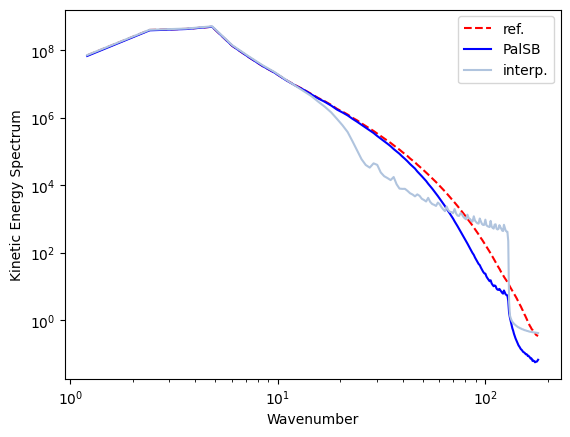

In [15]:
vor_kes = [scalar_inv(rearrange(v, 't c h w -> (t c) h w')) for v in [sampled_x0.numpy(), sampled_x1.numpy(), data_test]]

dx = 2 * np.pi / 256
dy = 2 * np.pi / 256
num_bins = 150
k, _ = kes_from_vorticity(samples_high[0, 0], dx=dx, dy=dy, num_bins=num_bins)

start = 0
end = len(vor_kes[0])

[E_mean_pred0, E_mean_pred1, E_mean_ref], _ = kes_plot(vor_kes,
                                        dx=dx, dy=dy, start=start, end=end, is_plot=False, num_bins=num_bins)
fig1, ax1 = plt.subplots()
ax1.loglog(k, E_mean_ref, label=f'ref.', ls='--', color='r')
ax1.loglog(k, E_mean_pred0, label=f'PalSB', color='b')
ax1.loglog(k, E_mean_pred1, label=f'interp.', color='lightsteelblue')
# ax1.loglog(k, E_mean_1, label='without para')
plt.xlabel('Wavenumber')
plt.ylabel('Kinetic Energy Spectrum')
plt.legend()
plt.show()